In [1]:
from pathlib import Path
from os import environ

try:
  import google.colab
  IN_COLAB = True

  # Cell 1 (Colab only - skip locally)
  !git clone https://github.com/RealAshrafAhmed/waterloo-slt-reading-group.git /content/repo
  %cd /content/repo
  !pip install uv && uv sync --all-packages
  # Cell 2 (both environments)
  from colab_extensions.env import setup
  env = setup()
  ROOT, DATA, OUTPUTS = env["ROOT"], env["DATA"], env["OUTPUTS"]
except ImportError:
  IN_COLAB = False
  if "DRIVE_HOME" in environ:
    ROOT = Path(f"{environ['DRIVE_HOME']}/colab/outputs/waterloo-slt-reading-group")
  else:
    ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
  basedir = Path(f"{ROOT}/mixture/poisson2d")
  datadir = Path(f"{basedir}/data")
  outputdir = Path(f"{basedir}/tempered")


if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/tempered


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [3]:
def find_truth_by_dsid(dsid: str):
    dgp = dgps.query(f"dsid=='{dsid}'")
    truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
    return truth

In [4]:
import numpy as np
regimes = np.array([50, 250, 5000])
target_beta = 1/np.sqrt(regimes)
print(target_beta)

[0.14142136 0.06324555 0.01414214]


In [5]:
beta_data = {}
for i, ivalue in enumerate(regimes):
  beta_data[i] = np.ones(len(target_beta))
  for j, jvalue in enumerate(target_beta):
    beta_data[i][j] = target_beta[i]/jvalue

print(beta_data)

{0: array([ 1.        ,  2.23606798, 10.        ]), 1: array([0.4472136 , 1.        , 4.47213595]), 2: array([0.1      , 0.2236068, 1.       ])}


In [ ]:
from pymc_extensions.tempered_mixpoisson import TemperedPoissonMixture
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az

n_components = 2

# mcmc settings
n_draws = 10000
n_tune = 10000

tempered_posterior_data = {}

for dsid in tqdm(dgps["dsid"].unique(), desc=f"class "):
  tempered_posterior_data[dsid] = {}
  for regime_index, regime in enumerate(tqdm(regimes, desc=f"dsid={dsid}, regime ")):
    tempered_posterior_data[dsid][regime] = {}
    dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
    X = dataset.iloc[:, 0].to_numpy()
    n_obs = len(X)
    # powers = [1, 0.5*np.sqrt(n_obs)/2, np.sqrt(n_obs), 2*np.sqrt(n_obs)]
    # betas= [1/p for p in powers]
    betas = beta_data[regime_index]

    for beta_index, beta in enumerate(tqdm(betas, desc=f"dsid={dsid}, regime={regime}")):
      tempered_posterior_data_file = Path(f"{outputdir}/tempered-posterior-{dsid}-{regime}-beta-{beta:.3f}.nc")
      
      if tempered_posterior_data_file.exists(): # check if this data has already been generated
        idata = az.from_netcdf(tempered_posterior_data_file)
        print(f"Loaded tempered (beta={beta}) posterior data from {tempered_posterior_data_file}!")
      else:
        with TemperedPoissonMixture(X=X, beta=beta, mus_log_prior_sigma=2) as model:
          idata = model.sample(draws=n_draws, 
                               tune=n_tune,
                               nuts_sampler="nutpie",
                               chains=16,
                               cores=16)
          idata.to_netcdf(tempered_posterior_data_file)
          print(f"File {tempered_posterior_data_file} created!.")
          tempered_posterior_data[dsid][regime][beta]=idata

class :   0%|          | 0/4 [00:00<?, ?it/s]

dsid=regular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

dsid=regular, regime=50:   0%|          | 0/3 [00:00<?, ?it/s]

Progress,Draws,Divergences,Step Size,Gradients/Draw
,20000,0,0.16,15
,20000,0,0.11,15
,20000,0,0.14,31
,20000,0,0.11,31
,20000,0,0.11,15
,20000,0,0.13,15
,20000,0,0.13,31
,20000,0,0.12,15
,20000,0,0.13,31
,20000,0,0.15,31


File /mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/tempered/tempered-posterior-regular-50-beta-1.000.nc created!.


...

File /mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/tempered/tempered-posterior-singular1-250-beta-1.000.nc created!.


Progress,Draws,Divergences,Step Size,Gradients/Draw
,20000,0,0.03,31
,20000,0,0.03,15
,20000,0,0.02,127
,20000,0,0.03,159
,20000,0,0.03,7
,20000,0,0.03,127
,20000,0,0.03,383
,20000,0,0.03,255
,20000,0,0.03,47
,20000,0,0.03,343


File /mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/tempered/tempered-posterior-singular1-250-beta-4.472.nc created!.


dsid=singular1, regime=5000:   0%|          | 0/3 [00:00<?, ?it/s]

Progress,Draws,Divergences,Step Size,Gradients/Draw
,13260,0,0.04,191
,13248,0,0.03,447
,14471,0,0.04,671
,14773,0,0.03,127
,12867,0,0.03,127
,13154,0,0.03,15
,16204,0,0.05,191
,12836,0,0.04,79
,13736,0,0.04,255
,15712,0,0.04,95


In [ ]:
# put the posteriors in a dataframe for easy visualization
joined_posterior_data = []
for dsid, dd in tempered_posterior_data.items():
    truth = find_truth_by_dsid(dsid=dsid)
    # dgp_weights = dgp[["w0", "w1"]].iloc[0].tolist()
    # dgp_mus = dgp[["m0", "m1"]].iloc[0].tolist()
    # truth = np.concatenate([dgp_mus, dgp_weights])
    for ss in regimes:
      regime_data = dd[ss]
      for ibeta, beta in enumerate(list(regime_data.keys())):
        idata = regime_data[beta]
        param_samples = az.extract(idata, var_names=["weights", "mus"])
        n_draws = param_samples.sizes["sample"]
        joined_posterior_data.append({
          "w0": param_samples["weights"][0,].values,
          "m0": param_samples["mus"][0,].values,
          "m1": param_samples["mus"][1,].values,
          "n": np.repeat(ss, n_draws),
          "beta": np.repeat(beta, n_draws),
          "ibeta": np.repeat(ibeta, n_draws),
          "dsid": np.repeat(dsid, n_draws)
        })

joined_posterior_df = pd.concat([pd.DataFrame(d) for d in joined_posterior_data], ignore_index=True)
joined_posterior_df.head()

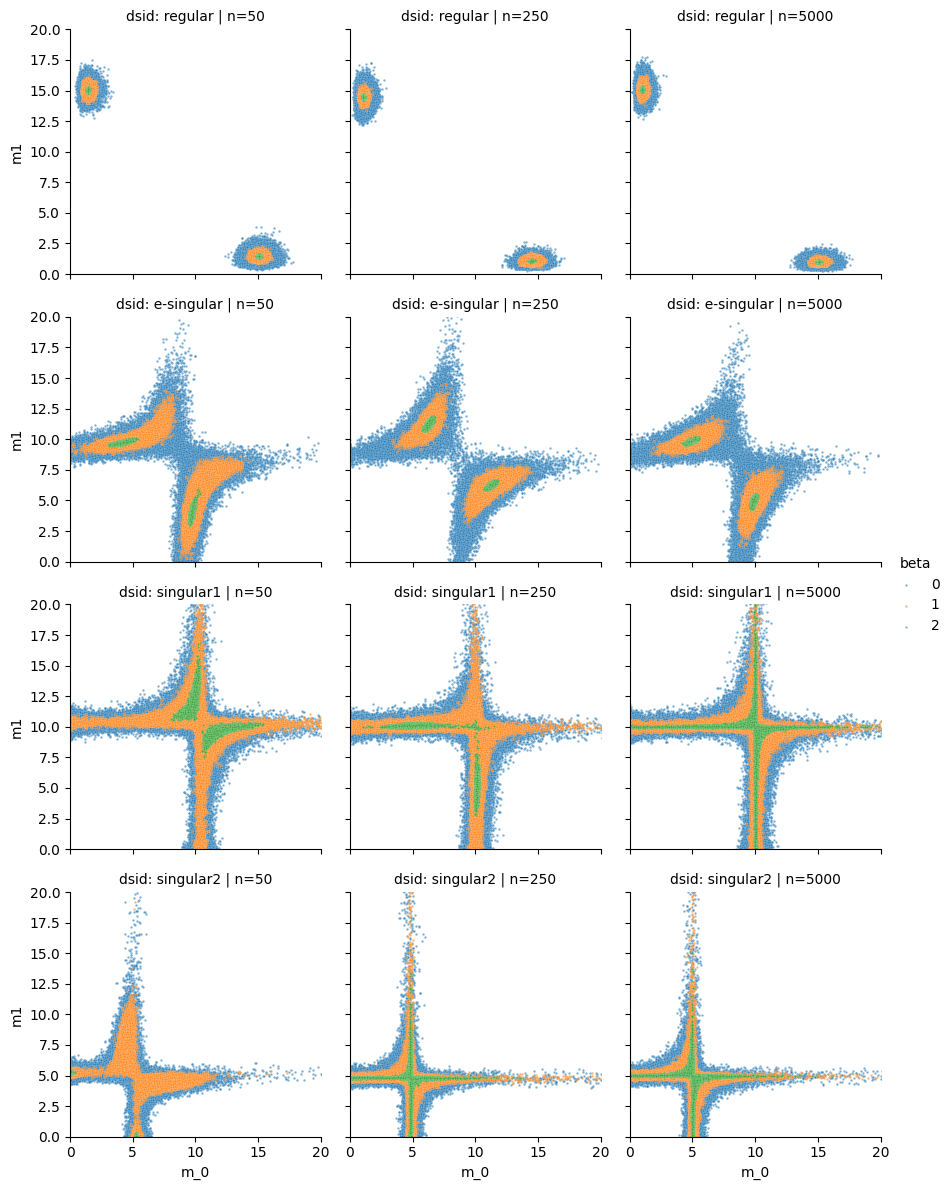

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", hue='ibeta', height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m0", "m1", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 20))
# Add labels and formatting
g.set_axis_labels("m_0", "m1")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
g.add_legend(title="beta")
plt.show()

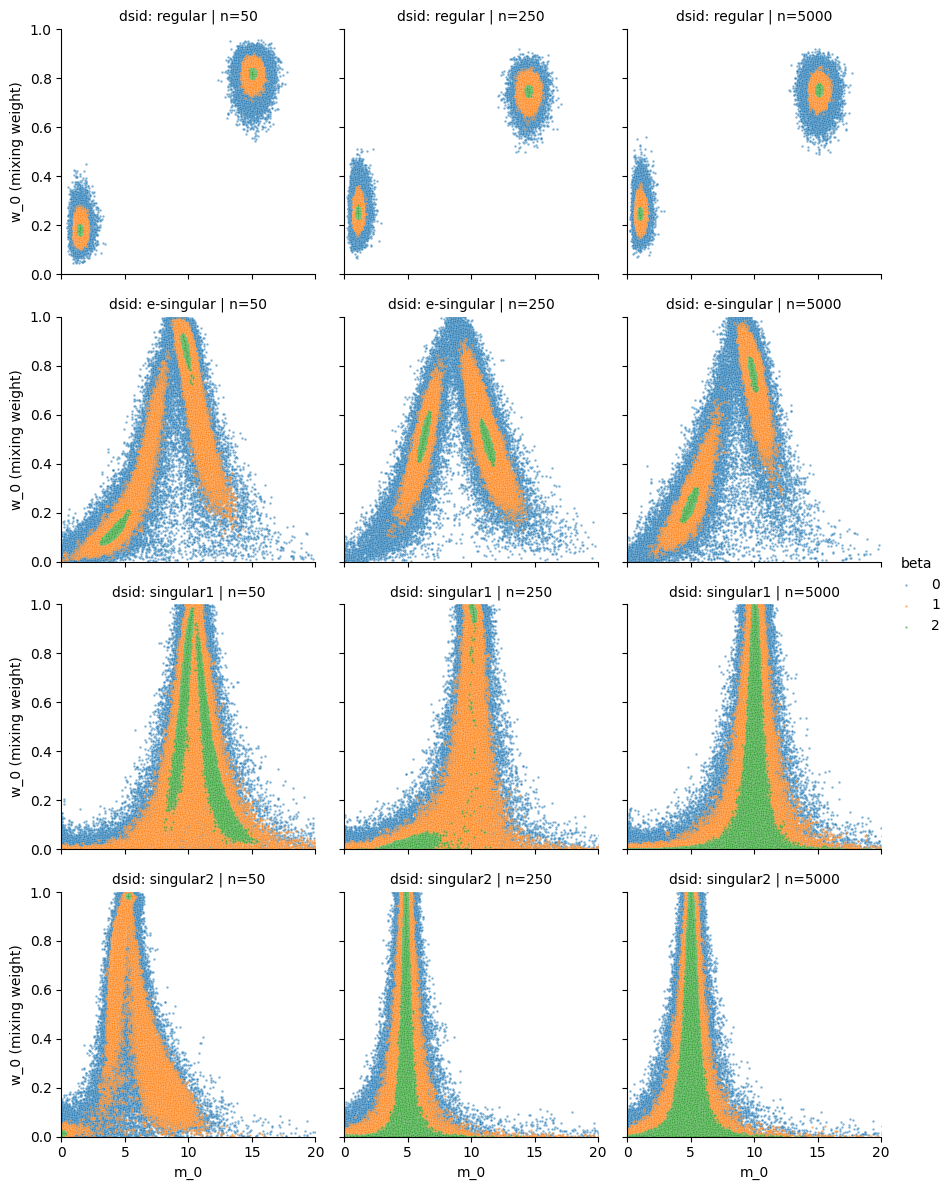

In [20]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", hue="ibeta", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m0", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_0", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
g.add_legend(title="beta")
plt.show()

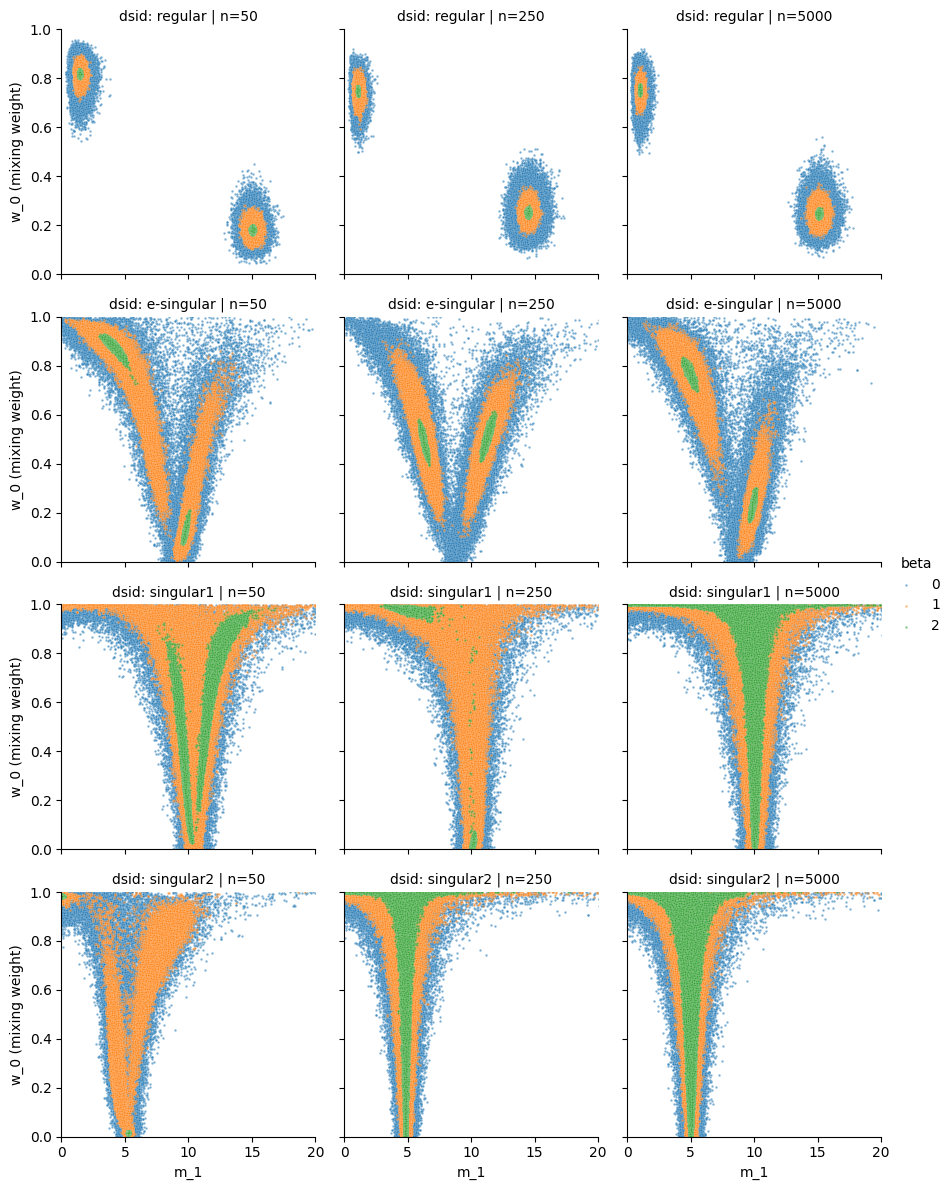

In [21]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", hue="ibeta", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m1", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_1", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
g.add_legend(title="beta")
plt.show()

In [22]:
def clean_for_plotting(
    arr, method="percentile", threshold=1000, percentile=95, handle_nan=True, clip=True
):
    """
    Universal cleaning function for plotting

    Parameters:
    -----------
    arr : array-like
    method : 'percentile' or 'threshold'
        How to determine replacement values
    threshold : float
        For 'threshold' method: distance from min/max
    percentile : float
        For 'percentile' method: which percentile to use
    handle_nan : bool
        Whether to replace NaN
    clip : bool
        Whether to clip to [min, max] range
    """
    arr = np.asarray(arr, dtype=float).copy()

    finite_mask = np.isfinite(arr)

    if not np.any(finite_mask):
        return np.zeros_like(arr)

    finite_values = arr[finite_mask]

    if method == "percentile":
        low_val = np.percentile(finite_values, 100 - percentile)
        high_val = np.percentile(finite_values, percentile)
        value_range = high_val - low_val
        margin = max(value_range * 0.1, abs(high_val) * 0.01, 1.0)
        replacement_low = low_val - margin
        replacement_high = high_val + margin
    else:  # threshold
        finite_min = finite_values.min()
        finite_max = finite_values.max()
        replacement_low = finite_min - threshold
        replacement_high = finite_max + threshold

    # Replace infinities
    arr = np.where(np.isneginf(arr), replacement_low, arr)
    arr = np.where(np.isposinf(arr), replacement_high, arr)

    if handle_nan:
        arr = np.where(np.isnan(arr), replacement_high, arr)

    if clip:
        arr = np.clip(arr, replacement_low, replacement_high)

    return arr

In [ ]:
def plot_kl_contours(data_df, profile_kl, plot_options={}, profile_options={}):
    plot_options = {
        "quantiles": np.array(
            [
                0.01,
                0.02,
                0.03,
                0.04,
                0.05,
                0.075,
                0.9,
                0.1,
                0.2,
                0.3,
                0.4,
                0.5,
                0.6,
                0.7,
                0.8,
                0.9,
                0.99,
            ]
        ),
        # "colors": ['#808080', '#A0A0A0', '#C0C0C0'],
        "figsize": (16, 6),
        "linewidths": 2.0,
        "cmap": "magma",
        "line_colors": "black",
        "label_fontsize": 1000,
    } | plot_options

    profile_options = {"grid_size": 100} | profile_options

    # Get unique values for facets
    dsids = data_df["dsid"].unique()
    n_obs_list = sorted(data_df["n"].unique())

    n_rows = len(dsids)
    n_cols = len(n_obs_list)

    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True, sharey=True)

    # Plot each panel
    for i, dsid in enumerate(tqdm(dsids, desc=f"datasets ")):
        # for i, dsid in enumerate(dsids):
        dgp = dgps.query(f"dsid=='{dsid}'")
        truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
        height = profile_kl(
            n_components=n_components,
            n_trials=n_trials,
            truth=truth,
            x_param={"name": "probs", "index": 0},
            y_param={"name": "probs", "index": 1},
            profile_grid_size=profile_options["grid_size"],
        )

        for j, n in enumerate(tqdm(sample_sizes, desc=f"{dsid} figures")):
            ax = axes[i, j]

            # Filter data for this combination
            subset = mles_df[(mles_df["dsid"] == dsid) & (mles_df["n"] == n)]

            # 1. computed profile KL values
            x = np.linspace(0, 1, 50)
            y = np.linspace(0, 1, 50)
            X, Y = np.meshgrid(x, y)
            Z = height(X, Y)

            # compoute contour levels for the quantiles
            # Z = clean_for_plotting(height(X,Y), method='percentile', percentile=0.999)
            levels = np.unique(np.quantile(Z, plot_options["quantiles"]))

            # align contours with levels
            n_levels = len(levels)
            cmap = plt.get_cmap("YlOrRd")
            colors = [cmap(q) for q in np.linspace(0, 1, n_levels)]

            cs = ax.contourf(
                X, Y, Z, levels=levels, colors=colors, alpha=0.8, extend="both"
            )
            cs_lines = ax.contour(X, Y, Z, levels=levels, colors="black", linewidths=1)
            # Create a dictionary mapping each level to its corresponding quantile value
            fmt = {}
            for l, level in enumerate(levels):
                if l < len(plot_options["quantiles"]):
                    # Just show the quantile value (e.g., "0.95")
                    fmt[level] = f"{plot_options['quantiles'][l]:.2f}"

            # Apply the custom labels
            ax.clabel(
                cs_lines,
                fontsize=6,
                inline=True,
                fmt=fmt,
                inline_spacing=10,
                colors="black",
                use_clabeltext=True,
            )

            # Scatter plot
            sns.scatterplot(data=subset, x="p0", y="p1", ax=ax, alpha=1, s=5)

            # Add title
            if i == 0:
                ax.set_title(f"n={n}", fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"dsid: {dsid}\np_0", fontweight="bold")
            else:
                ax.set_ylabel("p_1")

            if i == n_rows - 1:
                ax.set_xlabel("p_0")
            else:
                ax.set_xlabel("")
            # break
        # break
    return fig, axes


fig, axes = plot_kl_contours(
    mles_df, profile_kl=create_mixbinom_profile_kl, profile_options={"grid_size": 20}
)

plt.tight_layout()
fig.savefig(Path(f"{basedir}/mle/mles_with_kl.png"), dpi=600, bbox_inches="tight")
plt.show()